In [45]:
#########################################
#PLOTTING MRMS OUTPUT

In [46]:
#packages needed for plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.plots import ctables
import pandas as pd

In [47]:
# ============================================================
# Preload static map features (to avoid repeated downloads)
# ============================================================
COASTLINE = cfeature.COASTLINE.with_scale("50m")
STATES = cfeature.STATES.with_scale("50m")
BORDERS = cfeature.BORDERS.with_scale("50m")

# ============================================================
# Function: Plot MRMS reflectivity on a provided axis
# ============================================================
def PlotMRMSReflectivity(axis, data,
                         title_prefix="MRMS Reflectivity",
                         cmap_name="NWSReflectivity",
                         data_crs=ccrs.PlateCarree()):
    """
    Plot MRMS reflectivity (or similar data) on an existing Cartopy axis.

    Parameters
    ----------
    axis : cartopy.mpl.geoaxes.GeoAxesSubplot
        Axis to draw the map on (must be created with a Cartopy projection).
    data : xarray.DataArray
        MRMS reflectivity field with .latitude, .longitude, .time coords.
    title_prefix : str, optional
        Title text prefix (default: 'MRMS Reflectivity').
    cmap_name : str, optional
        Colormap name from MetPy ctables.
    data_crs : cartopy.crs projection, optional
        CRS of the data grid (usually PlateCarree for MRMS).
    """

    # --- Mask and extract ---
    data = data.where(data > 0, np.nan)
    lons = data.longitude
    lats = data.latitude
    values = data.values
    time_str = pd.to_datetime(data.time.values).strftime("%Y-%m-%d %H:%M UTC")

    # --- Domain bounds ---
    minLon, maxLon = float(lons.min()), float(lons.max())
    minLat, maxLat = float(lats.min()), float(lats.max())

    # --- Set map extent ---
    axis.set_extent([minLon, maxLon, minLat, maxLat], crs=data_crs)

    # --- Colormap ---
    ref_norm, ref_cmap = ctables.registry.get_with_steps(cmap_name, 5, 5)

    # --- Map features ---
    axis.add_feature(COASTLINE, linewidth=0.5)
    axis.add_feature(STATES, linewidth=0.5)
    axis.add_feature(BORDERS, linewidth=0.7)

    # --- Plot data ---
    mesh = axis.pcolormesh(
        lons, lats, values,
        transform=data_crs,
        cmap=ref_cmap, norm=ref_norm,
        shading="auto"
    )

    # --- Title ---
    axis.set_title(f"{title_prefix}\n{time_str}", fontsize=9, loc="left")

    # --- Tighten subplot area (no internal padding) ---
    axis.margins(0)
    axis.set_aspect("auto", adjustable="box")
    axis.set_anchor("C")

    return mesh  # return the QuadMesh for colorbar handling

In [64]:
def SelectNearestEvery6Hours(ds, hour_spacing=6, time_coord="time"):
    """
    Select data nearest to every 6-hour UTC mark (00, 06, 12, 18).

    Works even if the data has irregular or nonuniform timestamps.
    """
    times = pd.to_datetime(ds[time_coord].values)
    start = times.min().floor(f"{str(hour_spacing)}h")
    end   = times.max().ceil(f"{str(hour_spacing)}h")
    target_times = pd.date_range(start, end, freq=f"{str(hour_spacing)}h")

    nearest_indices = [np.argmin(np.abs(times - tt)) for tt in target_times]
    nearest_indices = sorted(set(nearest_indices))
    return ds.isel({time_coord: nearest_indices})

In [71]:
def MakePlotFigure_6hrPlot(Ntime):
    ncols = 3
    nrows = int(np.ceil(Ntime / ncols))
    
    fig = plt.figure(figsize=(5 * ncols, 4 * nrows))
    gs = gridspec.GridSpec(nrows, ncols,
                           left=0.03, right=0.90, bottom=0.05, top=0.95,
                           wspace=0.02, hspace=0.02)
    return fig,gs, ncols


def Make6hrPlot(data_subset):    
    Ntime = data_subset.sizes["time"]
    fig,gs, ncols = MakePlotFigure_6hrPlot(Ntime)
    
    axes = []
    for t in range(Ntime):
        row, col = divmod(t, ncols)
        ax = fig.add_subplot(gs[row, col], projection=ccrs.Mercator())
        data_t = data_subset.isel(time=t)['unknown']
        mesh = PlotMRMSReflectivity(ax, data_t)
        axes.append(ax)

    
    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(mesh, cax=cbar_ax)
    cbar.set_label("Reflectivity (dBZ)")
    
    fig.suptitle("MRMS Merged Reflectivity – TRACER Region",
                 fontsize=14, fontweight="bold", y=0.99)

In [ ]:
#########################################
#PLOTTING MRMS 

In [74]:
inputFile = "MRMSReflectivity_CONUS_TRACERregion_20220630-20220702.nc"
data_multi = xr.load_dataset(inputFile)
data_subset = SelectNearestEvery6Hours(data_multi,hour_spacing=6)

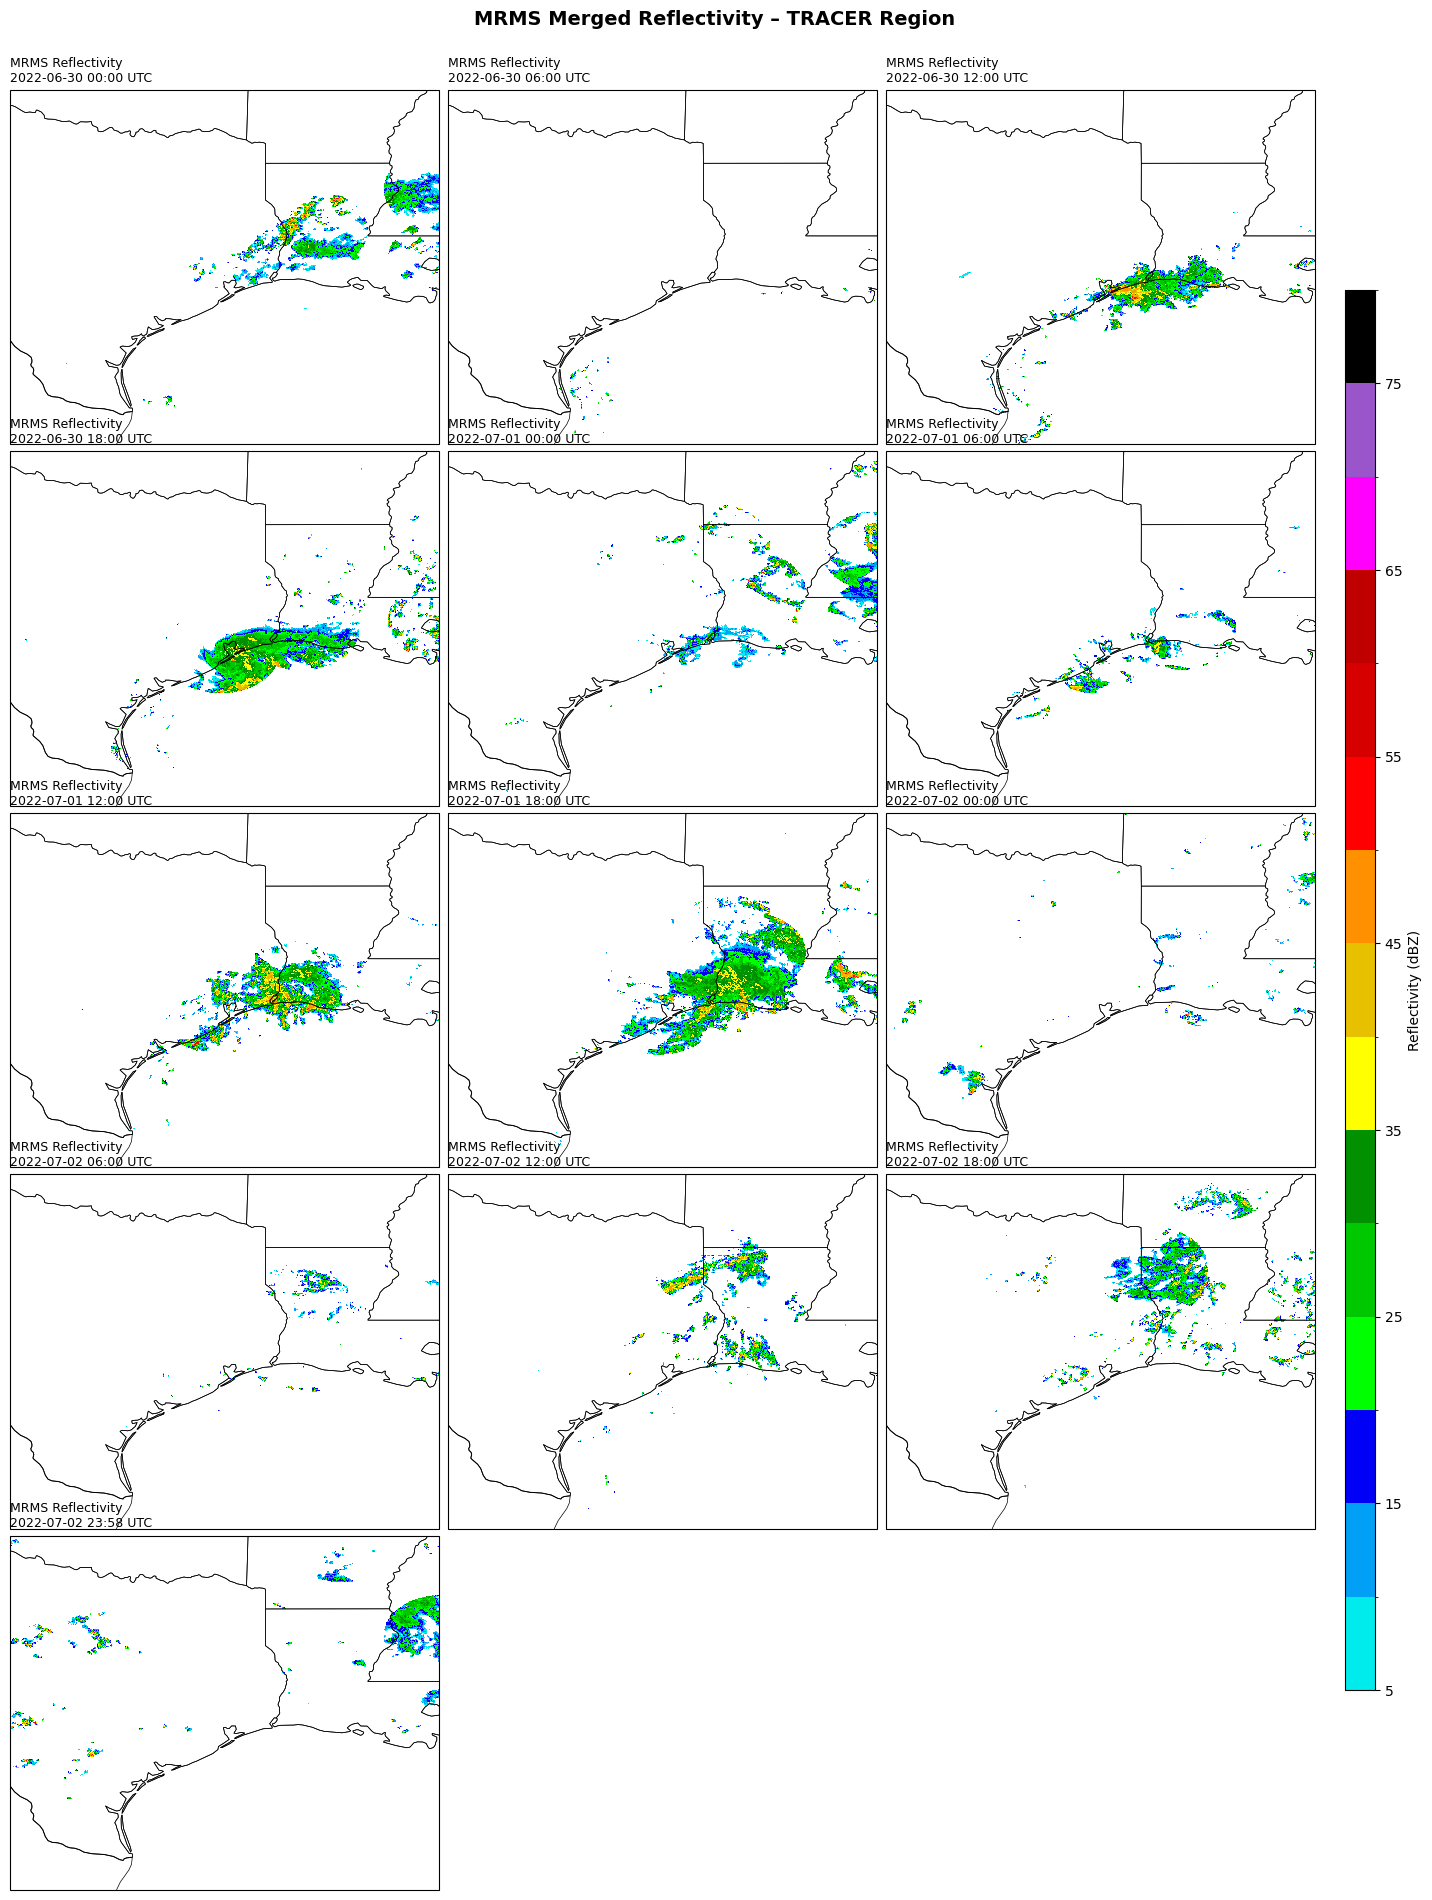

In [73]:
Make6hrPlot(data_subset)